In [11]:
pip install pandas nltk textblob matplotlib wordcloud

In [12]:
import nltk

nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [13]:
import pandas as pd
import re
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from textblob import TextBlob
from wordcloud import WordCloud
from collections import Counter

In [14]:
data = {
    "Review": [
        "I love this product. Amazing quality!",
        "Worst product I have ever bought.",
        "Delivery was very fast and on time.",
        "The packaging was damaged.",
        "Excellent customer service.",
        "Not worth the money.",
        "Very happy with my purchase.",
        "Battery life is too short.",
        "The design looks beautiful.",
        "Average quality, nothing special.",
        "Highly recommended to everyone.",
        "The app crashes frequently.",
        "Good value for money.",
        "Very disappointed with the performance.",
        "Fast shipping and excellent packaging.",
        "Customer support was helpful.",
        "The product stopped working after one week.",
        "Fantastic features and smooth performance.",
        "Poor build quality.",
        "It is okay, not bad.",
        "Amazing camera quality.",
        "The screen is bright and clear.",
        "Terrible experience with delivery.",
        "Easy to use and user-friendly.",
        "The sound quality is excellent.",
        "I will never buy this again.",
        "Satisfied with the purchase.",
        "The color is exactly as shown.",
        "Very slow response from customer support.",
        "Best product in this price range."
    ]
}

In [15]:
df = pd.DataFrame(data)

In [16]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    words = word_tokenize(text)
    words = [word for word in words if word not in stop_words]
    words = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(words)

In [18]:
df["Clean Review"] = df["Review"].apply(clean_text)
print(df.head())

                                  Review                  Clean Review
0  I love this product. Amazing quality!  love product amazing quality
1      Worst product I have ever bought.     worst product ever bought
2    Delivery was very fast and on time.            delivery fast time
3             The packaging was damaged.             packaging damaged
4            Excellent customer service.    excellent customer service


In [19]:
def get_sentiment(text):
    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"
    elif polarity < 0:
        return "Negative"
    else:
        return "Neutral"

2

2

In [21]:
df["Sentiment"] = df["Clean Review"].apply(get_sentiment)
print(df[["Review","Sentiment"]])

                                         Review Sentiment
0         I love this product. Amazing quality!  Positive
1             Worst product I have ever bought.  Negative
2           Delivery was very fast and on time.  Positive
3                    The packaging was damaged.   Neutral
4                   Excellent customer service.  Positive
5                          Not worth the money.  Positive
6                  Very happy with my purchase.  Positive
7                    Battery life is too short.   Neutral
8                   The design looks beautiful.  Positive
9             Average quality, nothing special.  Positive
10              Highly recommended to everyone.  Positive
11                  The app crashes frequently.  Positive
12                        Good value for money.  Positive
13      Very disappointed with the performance.  Negative
14       Fast shipping and excellent packaging.  Positive
15                Customer support was helpful.   Neutral
16  The produc

In [22]:
print(df["Sentiment"].value_counts())

Sentiment
Positive    19
Negative     6
Neutral      5
Name: count, dtype: int64


In [23]:
all_words = " ".join(df["Clean Review"])
word_list = all_words.split()
word_freq = Counter(word_list)
print(word_freq.most_common(10))

[('quality', 5), ('product', 4), ('excellent', 3), ('customer', 3), ('amazing', 2), ('delivery', 2), ('fast', 2), ('packaging', 2), ('money', 2), ('purchase', 2)]


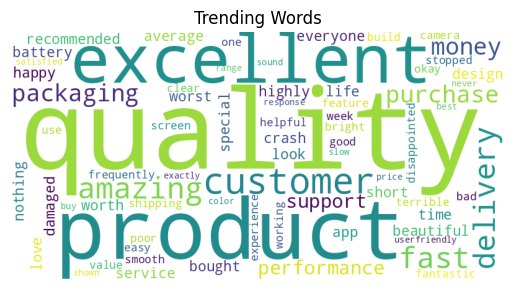

In [24]:
wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(all_words)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Trending Words")
plt.show()

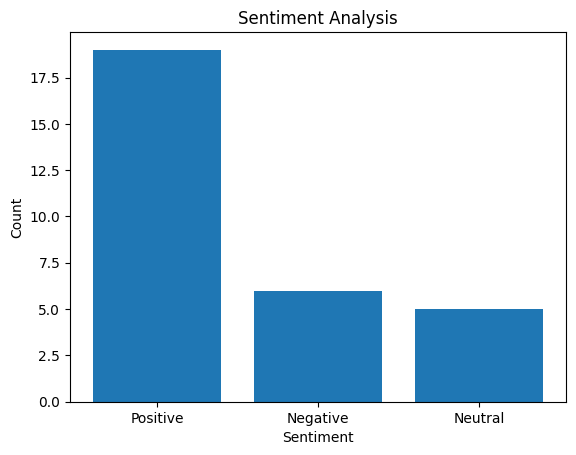

In [25]:
sentiment_count = df["Sentiment"].value_counts()
plt.bar(sentiment_count.index, sentiment_count.values)
plt.title("Sentiment Analysis")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

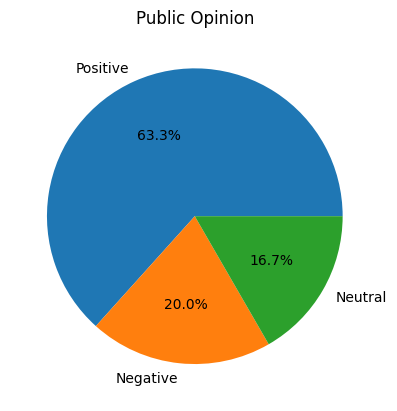

In [26]:
sentiment_count.plot(
    kind="pie",
    autopct="%1.1f%%"
)
plt.ylabel("")
plt.title("Public Opinion")
plt.show()